# Tutorial

## Tutorial

### Setting up environment

In [1]:
import sys
import os
code_folder = "C:/Users/bpeng/OneDrive - J. Craig Venter Institute/Documents/Github/NSForest"
sys.path.insert(0, os.path.abspath(code_folder))
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import nsforest as ns
from nsforest import utils
from nsforest import preprocessing as pp
from nsforest import nsforesting
from nsforest import evaluating as ev
from nsforest import plotting as pl

### Data Exploration

#### Loading h5ad AnnData file

In [2]:
data_folder = "../demo_data/"
file = data_folder + "adata_layer1.h5ad"
adata = sc.read_h5ad(file)
adata

AnnData object with n_obs × n_vars = 871 × 16497
    obs: 'cluster'

#### Defining `cluster_header` as cell type annotation. 

**Note:** Some datasets have multiple annotations per sample (ex. "broad_cell_type" and "granular_cell_type"). NS-Forest can be run on multiple `cluster_header`'s. Combining the parent and child markers may improve classification results. 

In [3]:
cluster_header = "cluster"

#### Defining `output_folder` for saving results

In [4]:
output_folder = "../outputs_layer1/"

#### Looking at sample labels

In [5]:
adata.obs_names

Index(['A01_1_Nuclei_NeuNP_H200_1025_MTG_layer1_BCH9',
       'A01_BCH3_1NeuNP_H200.1030_MTG_Layer_1',
       'A02_BCH1_1NeuNP_H200.1025_MTG_layer_1',
       'A03_1_Nuclei_NeuNP_H200_1025_MTG_layer1_BCH9',
       'A04_1_Nuclei_NeuNP_H200_1025_MTG_layer1_BCH9',
       'A04_BCH1_1NeuNP_H200.1025_MTG_layer_1',
       'A04_BCH3_1NeuNP_H200.1030_MTG_Layer_1',
       'A05_1_Nuclei_NeuNP_H200_1025_MTG_layer1_BCH9',
       'A05_BCH1_1NeuNP_H200.1025_MTG_layer_1',
       'A05_BCH3_1NeuNP_H200.1030_MTG_Layer_1',
       ...
       'P09_1_Nuclei_NeuNN_H200_1025_MTG_layer1_BCH7',
       'P09_1_Nuclei_NeuNN_H200_1025_MTG_layer1_BCH9',
       'P09_1_Nuclei_NeuNN_H200_1030_MTG_layer1_BCH8',
       'P09_BCH1_1NeuNN_H200.1025_MTG_layer_1',
       'P10_1_Nuclei_NeuNN_H200_1025_MTG_layer1_BCH6',
       'P10_1_Nuclei_NeuNN_H200_1025_MTG_layer1_BCH9',
       'P10_BCH1_1NeuNN_H200.1025_MTG_layer_1',
       'P11_1_Nuclei_NeuNN_H200_1025_MTG_layer1_BCH7',
       'P11_1_Nuclei_NeuNN_H200_1025_MTG_layer1_BCH9',


#### Looking at genes

**Note:** `adata.var_names` must be unique. If there is a problem, usually it can be solved by assigning `adata.var.index = adata.var["ensembl_id"]`. 

In [6]:
adata.var_names

Index(['A1CF', 'A2M', 'A2M_AS1', 'A2ML1', 'A2ML1_AS1', 'A2MP1', 'A3GALT2',
       'A4GALT', 'AAAS', 'AACS',
       ...
       'ZUFSP', 'ZW10', 'ZWILCH', 'ZWINT', 'ZXDC', 'ZYG11A', 'ZYG11B', 'ZYX',
       'ZZEF1', 'ZZZ3'],
      dtype='object', length=16497)

#### Checking cell annotation sizes 

**Note:** Some datasets are too large and need to be downsampled to be run through the pipeline. When downsampling, be sure to have all the granular cluster annotations represented. 

In [7]:
pd.DataFrame(adata.obs[cluster_header].value_counts()).reset_index()

,cluster,count
0,e1_e299_SLC17A7_L5b_Cdh13,299
1,i1_i90_COL5A2_Ndnf_Car4,90
2,i2_i77_LHX6_Sst_Cbln4,77
3,i3_i56_BAGE2_Ndnf_Cxcl14,56
4,i4_i54_MC4R_Ndnf_Cxcl14,54
5,g1_g48_GLI3_Astro_Gja1,48
6,i5_i47_TRPC3_Ndnf_Car4,47
7,i6_i44_GPR149_Vip_Mybpc1,44
8,i7_i31_CLMP_Ndnf_Cxcl14,31
9,g2_g27_APBB1IP_Micro_Ctss,27


### Preprocessing

#### Generating scanpy dendrogram

**Note:** Only run if there is no pre-defined dendrogram order. This step can still be run with no effects, but the runtime may increase. 

Dendrogram order is stored in `adata.uns["dendrogram_cluster"]["categories_ordered"]`. 

Saving dendrogram as...
../outputs_layer1/_cluster.png


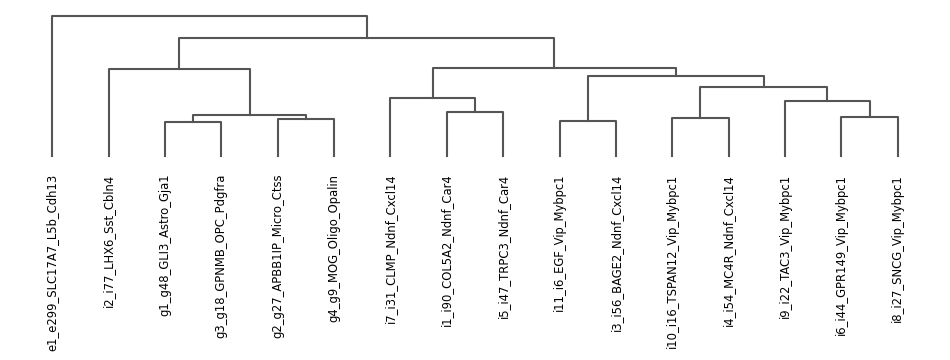

In [8]:
ns.pp.dendrogram(adata, cluster_header, save = True, output_folder = output_folder, outputfilename_suffix = cluster_header)

#### Calculating cluster medians per gene

Run `ns.pp.prep_medians` before running NS-Forest.

**Note:** Do **not** run if evaluating marker lists. Do **not** run when generating scanpy plots (e.g. dot plot, violin plot, matrix plot). 

In [9]:
adata = ns.pp.prep_medians(adata, cluster_header)
adata.varm["medians_cluster"]

Calculating medians per cluster: 100%|██████████| 16/16 [00:01<00:00, 12.87it/s]


Saving calculated medians as adata.varm.medians_cluster
median: 0.0
mean: 1.626
std: 2.49
Only positive genes selected. 11688 positive genes out of 16497 total genes
--- 1.6195251941680908 seconds ---


,e1_e299_SLC17A7_L5b_Cdh13,g1_g48_GLI3_Astro_Gja1,g2_g27_APBB1IP_Micro_Ctss,g3_g18_GPNMB_OPC_Pdgfra,g4_g9_MOG_Oligo_Opalin,i10_i16_TSPAN12_Vip_Mybpc1,i11_i6_EGF_Vip_Mybpc1,i1_i90_COL5A2_Ndnf_Car4,i2_i77_LHX6_Sst_Cbln4,i3_i56_BAGE2_Ndnf_Cxcl14,i4_i54_MC4R_Ndnf_Cxcl14,i5_i47_TRPC3_Ndnf_Car4,i6_i44_GPR149_Vip_Mybpc1,i7_i31_CLMP_Ndnf_Cxcl14,i8_i27_SNCG_Vip_Mybpc1,i9_i22_TAC3_Vip_Mybpc1
A2M,0.000000,1.584962,8.985842,1.000000,0.000000,0.000000,1.792481,0.000000,0.000000,1.000000,0.000000,1.000000,1.292481,0.000000,1.000000,0.500000
A2M_AS1,0.000000,0.000000,3.169925,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
A2ML1_AS1,4.392317,7.832668,1.584962,4.253898,0.000000,6.400854,3.683161,4.522197,4.754888,2.403677,4.321928,5.392317,4.459432,5.209454,5.727921,5.096147
A2MP1,0.000000,0.000000,0.000000,0.000000,1.584962,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
AAAS,0.000000,1.292481,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYG11A,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ZYG11B,4.857981,1.000000,1.000000,0.000000,2.584963,3.836213,6.346526,5.491853,3.906891,3.064641,3.903677,5.781360,5.584649,6.475733,5.614710,5.931125
ZYX,3.169925,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ZZEF1,4.392317,1.584962,2.321928,0.000000,1.000000,4.215226,5.734567,3.390680,1.584962,1.584962,2.321928,3.169925,3.229716,4.392317,3.584963,2.660964


#### Calculating binary scores per gene per cluster

Run `ns.pp.prep_binary_scores` before running NS-Forest. Do not need to run if evaluating marker lists. Do not need to run when generating scanpy plots. 

In [10]:
adata = ns.pp.prep_binary_scores(adata, cluster_header)
adata.varm["binary_scores_cluster"]

Calculating binary scores per cluster: 100%|██████████| 16/16 [01:28<00:00,  5.56s/it]


Saving calculated binary scores as adata.varm.binary_scores_cluster
median: 0.1
mean: 0.202
std: 0.252
--- 89.41979765892029 seconds ---


,e1_e299_SLC17A7_L5b_Cdh13,g1_g48_GLI3_Astro_Gja1,g2_g27_APBB1IP_Micro_Ctss,g3_g18_GPNMB_OPC_Pdgfra,g4_g9_MOG_Oligo_Opalin,i10_i16_TSPAN12_Vip_Mybpc1,i11_i6_EGF_Vip_Mybpc1,i1_i90_COL5A2_Ndnf_Car4,i2_i77_LHX6_Sst_Cbln4,i3_i56_BAGE2_Ndnf_Cxcl14,i4_i54_MC4R_Ndnf_Cxcl14,i5_i47_TRPC3_Ndnf_Car4,i6_i44_GPR149_Vip_Mybpc1,i7_i31_CLMP_Ndnf_Cxcl14,i8_i27_SNCG_Vip_Mybpc1,i9_i22_TAC3_Vip_Mybpc1
A2M,0.000000,0.623023,0.931968,0.500000,0.000000,0.000000,0.658949,0.000000,0.000000,0.500000,0.000000,0.500000,0.567888,0.000000,0.500000,0.466667
A2M_AS1,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
A2ML1_AS1,0.153393,0.470567,0.066667,0.146435,0.000000,0.352137,0.127804,0.163316,0.184686,0.089374,0.149377,0.247584,0.158108,0.228193,0.283856,0.216961
A2MP1,0.000000,0.000000,0.000000,0.000000,0.915876,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.866667,0.866667,0.000000
AAAS,0.000000,0.948420,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.933333,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYG11A,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ZYG11B,0.268527,0.066667,0.066667,0.000000,0.148420,0.200397,0.381241,0.306785,0.204062,0.166928,0.203846,0.328997,0.312765,0.393586,0.315017,0.342573
ZYX,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ZZEF1,0.401457,0.091271,0.168100,0.000000,0.066667,0.381913,0.541554,0.284062,0.091271,0.091271,0.168100,0.258675,0.264994,0.401457,0.308410,0.206141


#### Plotting median and binary score distributions

Saving median distributions as...
../outputs_layer1/cluster_medians.png


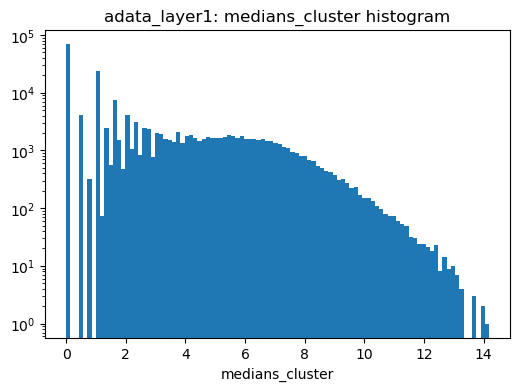

In [11]:
filename = output_folder + cluster_header + '_medians.png'
print(f"Saving median distributions as...\n{filename}")
a = plt.figure(figsize = (6, 4))
a = plt.hist(adata.varm["medians_" + cluster_header].unstack(), bins = 100)
a = plt.title(f'{file.split("/")[-1].replace(".h5ad", "")}: {"medians_" + cluster_header} histogram')
a = plt.xlabel("medians_" + cluster_header)
a = plt.yscale("log")
a = plt.savefig(filename, bbox_inches='tight')
plt.show()

Saving binary_score distributions as...
../outputs_layer1/cluster_binary_scores.png


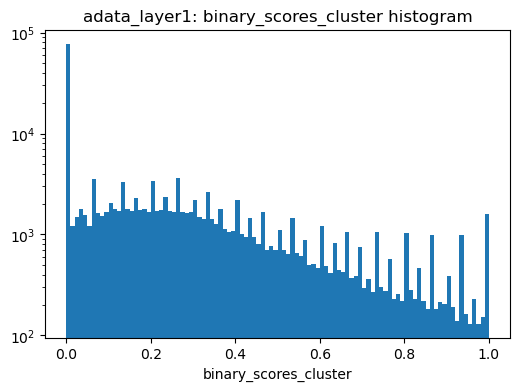

In [12]:
filename = output_folder + cluster_header + '_binary_scores.png'
print(f"Saving binary_score distributions as...\n{filename}")
a = plt.figure(figsize = (6, 4))
a = plt.hist(adata.varm["binary_scores_" + cluster_header].unstack(), bins = 100)
a = plt.title(f'{file.split("/")[-1].replace(".h5ad", "")}: {"binary_scores_" + cluster_header} histogram')
a = plt.xlabel("binary_scores_" + cluster_header)
a = plt.yscale("log")
a = plt.savefig(filename, bbox_inches='tight')
plt.show()

#### Saving preprocessed AnnData as new h5ad

In [13]:
filename = file.replace(".h5ad", "_preprocessed.h5ad")
print(f"Saving new anndata object as...\n{filename}")
adata.write_h5ad(filename)
adata

Saving new anndata object as...
../demo_data/adata_layer1_preprocessed.h5ad


AnnData object with n_obs × n_vars = 871 × 11688
    obs: 'cluster'
    uns: 'pca', 'dendrogram_cluster'
    obsm: 'X_pca'
    varm: 'PCs', 'medians_cluster', 'binary_scores_cluster'

### Running NS-Forest

**Note:** Do not run NS-Forest if only evaluating input marker lists. 

In [14]:
outputfilename_prefix = cluster_header
results = nsforesting.NSForest(adata, cluster_header, save_supplementary = True, save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)

Running NS-Forest version 4.1

Preparing adata...
Pre-selecting genes based on binary scores...
	BinaryFirst_high Threshold (mean + 2 * std): 0.706
	Average number of genes after gene_selection in each cluster: 735.5
Saving number of genes selected per cluster as...
../outputs_layer1/cluster_gene_selection.csv
--- 0.055999755859375 seconds ---

Number of clusters to evaluate: 16
1 out of 16:
	e1_e299_SLC17A7_L5b_Cdh13
	Pre-selected 1356 genes to feed into Random Forest.
	NSForest-selected markers: ['LINC00507']
	fbeta: 0.96
	precision: 0.978
	recall: 0.893
2 out of 16:
	g1_g48_GLI3_Astro_Gja1
	Pre-selected 583 genes to feed into Random Forest.
	NSForest-selected markers: ['LINC00498']
	fbeta: 0.95
	precision: 1.0
	recall: 0.792
3 out of 16:
	g2_g27_APBB1IP_Micro_Ctss
	Pre-selected 420 genes to feed into Random Forest.
	NSForest-selected markers: ['ADAM28', 'PTPRC']
	fbeta: 0.976
	precision: 1.0
	recall: 0.889
4 out of 16:
	g3_g18_GPNMB_OPC_Pdgfra
	Pre-selected 353 genes to feed into Ra

Calculating medians per cluster: 100%|██████████| 16/16 [00:00<00:00, 389.90it/s]

Saving supplementary table as...
../outputs_layer1/cluster_markers_onTarget_supp.csv
Saving supplementary table as...
../outputs_layer1/cluster_markers_onTarget.csv

Saving final results table as...
../outputs_layer1/cluster_results.csv
Saving final results table as...
../outputs_layer1/cluster_results.pkl


In [15]:
results

,software_version,cluster_header,clusterName,clusterSize,f_score,precision,recall,TN,FP,FN,TP,marker_count,NSForest_markers,binary_genes,onTarget
0,4.1,cluster,e1_e299_SLC17A7_L5b_Cdh13,299,0.959741,0.978022,0.892977,566,6,32,267,1,[LINC00507],"[SLC17A7, LINC00508, TBR1, ANKRD33B, NPTX1, LI...",0.792614
1,4.1,cluster,g1_g48_GLI3_Astro_Gja1,48,0.950000,1.000000,0.791667,823,0,10,38,1,[LINC00498],"[LINC00498, SLC25A18, EMX2OS, FAM189A2, SLC7A1...",1.000000
2,4.1,cluster,g2_g27_APBB1IP_Micro_Ctss,27,0.975610,1.000000,0.888889,844,0,3,24,2,"[ADAM28, PTPRC]","[ADAM28, PLCG2, INPP5D, PTPRC, CSF2RA, P2RY13,...",1.000000
3,4.1,cluster,g3_g18_GPNMB_OPC_Pdgfra,18,0.862069,1.000000,0.555556,853,0,8,10,2,"[GPNMB, OLIG2]","[GPNMB, COL20A1, OLIG2, STK32A, KLRC3, KLRC2, ...",1.000000
4,4.1,cluster,g4_g9_MOG_Oligo_Opalin,9,1.000000,1.000000,1.000000,862,0,0,9,1,[ST18],"[ST18, MOBP, CNDP1, MOG, CD22, FOLH1, TF, CARN...",1.000000
5,4.1,cluster,i10_i16_TSPAN12_Vip_Mybpc1,16,0.803571,0.900000,0.562500,854,1,7,9,2,"[TSPAN12, CHRNB3]","[TSPAN12, TMC5, LINC01539, CHRNB3, FAM46A, ANG...",0.783762
6,4.1,cluster,i11_i6_EGF_Vip_Mybpc1,6,0.714286,1.000000,0.333333,865,0,4,2,2,"[EGF, FBRSL1]","[EGF, FZD8, KCNJ2_AS1, FBRSL1, TEKT1, NRG3_AS1...",1.000000
7,4.1,cluster,i1_i90_COL5A2_Ndnf_Car4,90,0.907821,0.970149,0.722222,779,2,25,65,2,"[COL5A2, BMP6]","[NMBR, COL5A2, C8ORF4, PAPSS2, TRPC3, BMP6, SS...",0.642585
8,4.1,cluster,i2_i77_LHX6_Sst_Cbln4,77,0.816619,0.838235,0.740260,783,11,20,57,1,[LHX6],"[LHX6, FLT3, TAC1, CALB1, RSPO3, TRBC2, GRIK3,...",1.000000
9,4.1,cluster,i3_i56_BAGE2_Ndnf_Cxcl14,56,0.781250,0.961538,0.446429,814,1,31,25,2,"[BAGE2, SYT10]","[BAGE2, SCN5A, GREM2, FAM19A4, SYT10, ARHGAP18...",0.602383


### Plotting scanpy dot plot, violin plot, matrix plot for NS-Forest markers

**Note:** Assign pre-defined dendrogram order here **or** use `adata.uns["dendrogram_" + cluster_header]["categories_ordered"]`. 

In [16]:
to_plot = results.copy()

In [17]:
dendrogram = [] # custom dendrogram order
dendrogram = list(adata.uns["dendrogram_" + cluster_header]["categories_ordered"])
to_plot["clusterName"] = to_plot["clusterName"].astype("category")
to_plot["clusterName"] = to_plot["clusterName"].cat.set_categories(dendrogram)
to_plot = to_plot.sort_values("clusterName")
to_plot = to_plot.rename(columns = {"NSForest_markers": "markers"})

In [18]:
markers_dict = dict(zip(to_plot["clusterName"], to_plot["markers"]))
markers_dict

{'e1_e299_SLC17A7_L5b_Cdh13': ['LINC00507'],
 'i2_i77_LHX6_Sst_Cbln4': ['LHX6'],
 'g1_g48_GLI3_Astro_Gja1': ['LINC00498'],
 'g3_g18_GPNMB_OPC_Pdgfra': ['GPNMB', 'OLIG2'],
 'g2_g27_APBB1IP_Micro_Ctss': ['ADAM28', 'PTPRC'],
 'g4_g9_MOG_Oligo_Opalin': ['ST18'],
 'i7_i31_CLMP_Ndnf_Cxcl14': ['PAX6', 'TGFBR2'],
 'i1_i90_COL5A2_Ndnf_Car4': ['COL5A2', 'BMP6'],
 'i5_i47_TRPC3_Ndnf_Car4': ['NTNG1', 'EYA4'],
 'i11_i6_EGF_Vip_Mybpc1': ['EGF', 'FBRSL1'],
 'i3_i56_BAGE2_Ndnf_Cxcl14': ['BAGE2', 'SYT10'],
 'i10_i16_TSPAN12_Vip_Mybpc1': ['TSPAN12', 'CHRNB3'],
 'i4_i54_MC4R_Ndnf_Cxcl14': ['ARHGAP36', 'ADAM33'],
 'i9_i22_TAC3_Vip_Mybpc1': ['BSPRY', 'MCTP2'],
 'i6_i44_GPR149_Vip_Mybpc1': ['FLT1', 'GPR149'],
 'i8_i27_SNCG_Vip_Mybpc1': ['SNCG', 'EDNRA']}

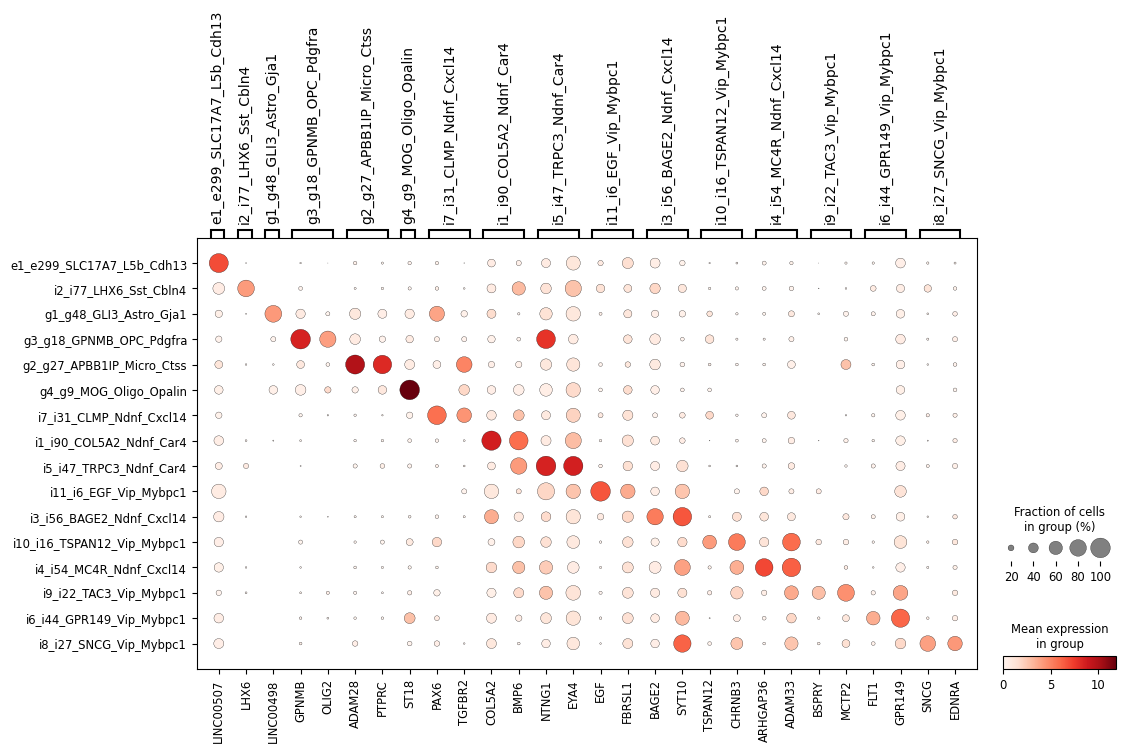

In [19]:
ns.pl.dotplot(adata, markers_dict, cluster_header, dendrogram = dendrogram, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix)

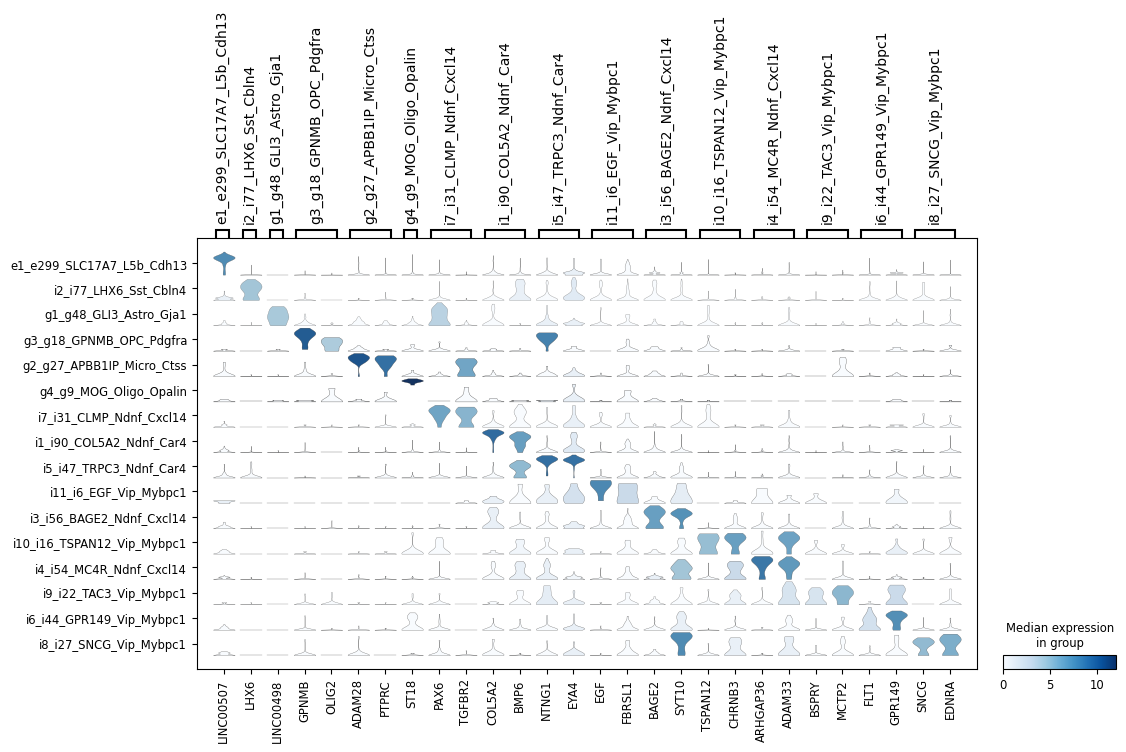

In [20]:
ns.pl.stackedviolin(adata, markers_dict, cluster_header, dendrogram = dendrogram, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix)

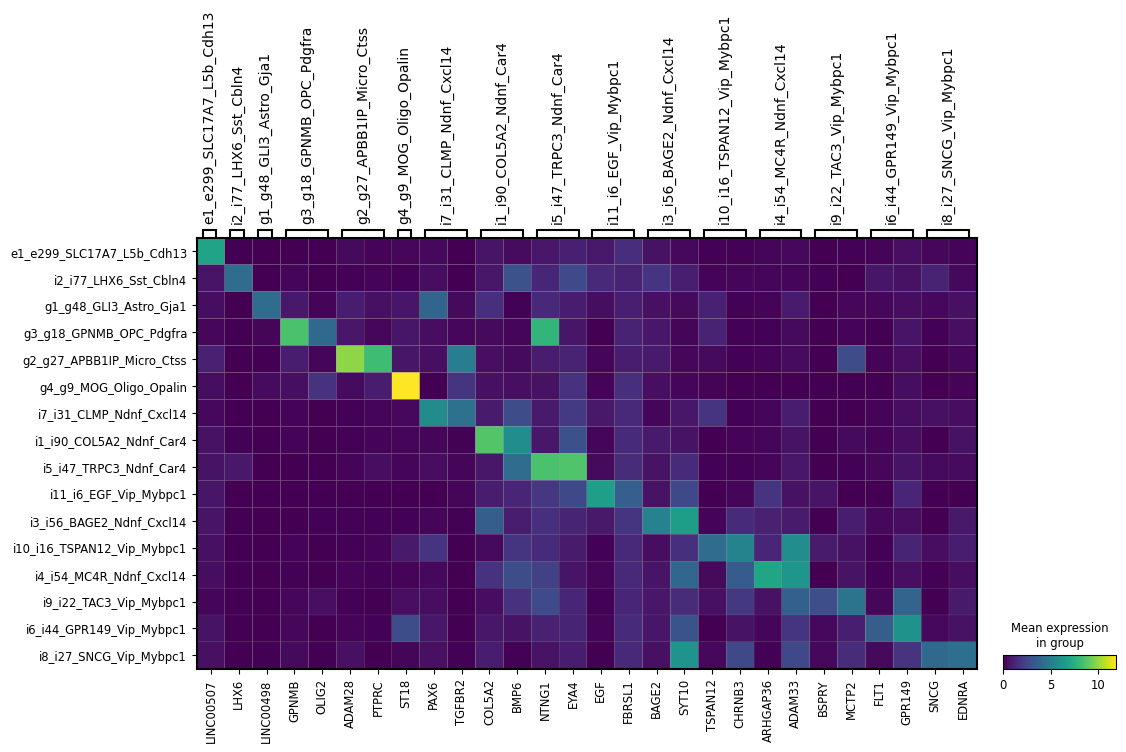

In [21]:
ns.pl.matrixplot(adata, markers_dict, cluster_header, dendrogram = dendrogram, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix)

#### Plotting classification metrics from NS-Forest results

Saving...
 ../outputs_layer1/cluster_boxplot_f_score_precision_recall_onTarget.html


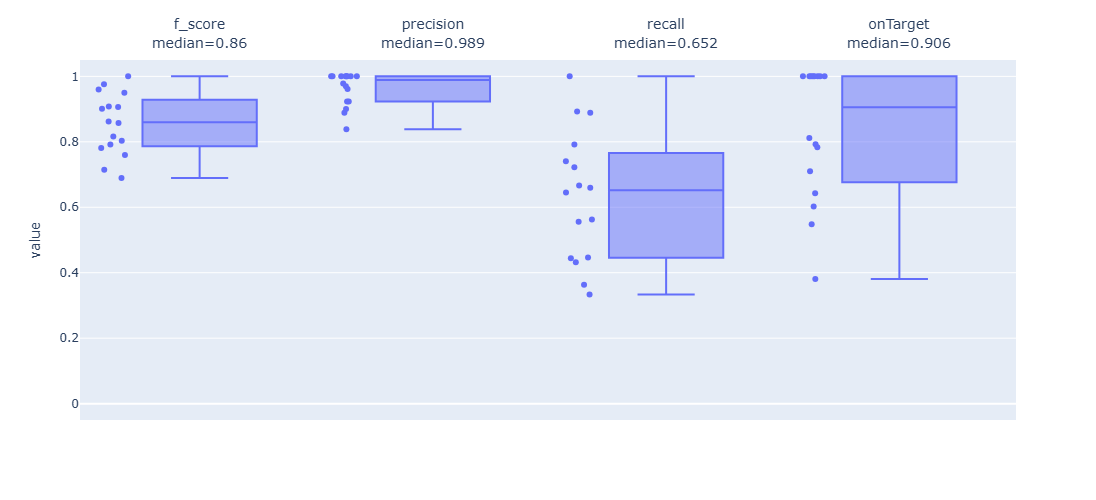

In [22]:
ns.pl.boxplot(results, ["f_score", "precision", "recall", "onTarget"], save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)

#### Plotting individual classification metrics

Saving...
 ../outputs_layer1/cluster_boxplot_f_score.html


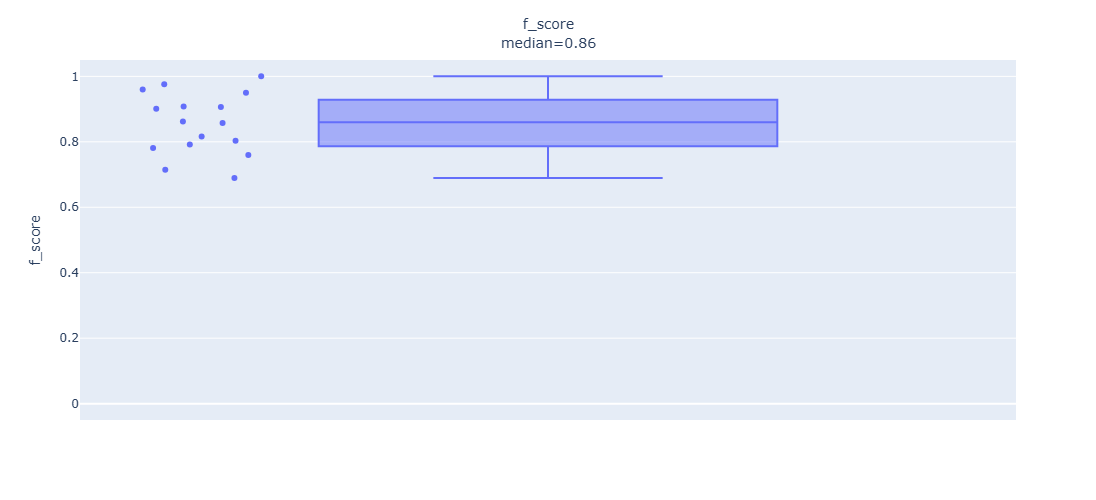

In [23]:
ns.pl.boxplot(results, "f_score", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)

#### Plotting metrics vs clusterSize

Saving...
 ../outputs_layer1/cluster_scatter_f_score.html


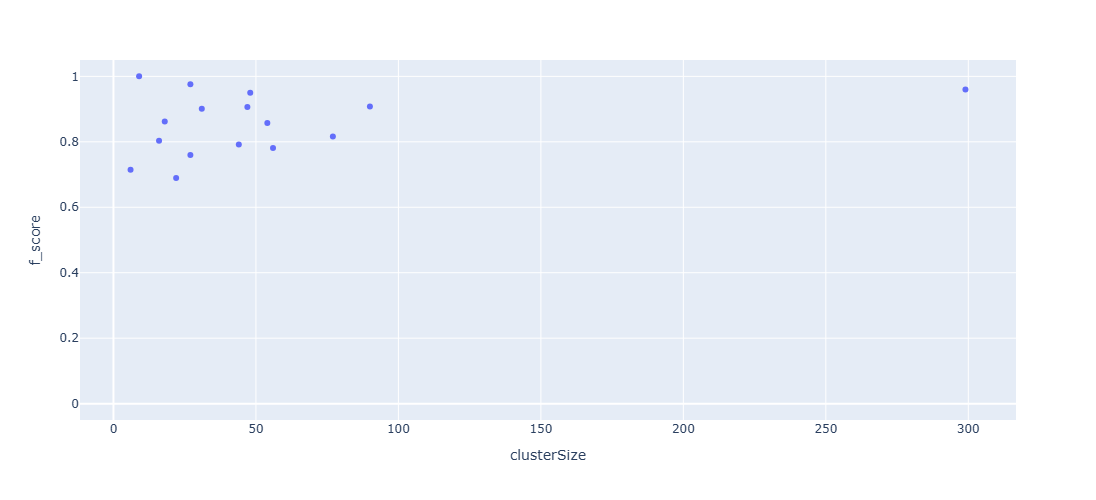

In [24]:
ns.pl.scatter_w_clusterSize(results, "f_score", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)

Saving...
 ../outputs_layer1/cluster_scatter_precision.html


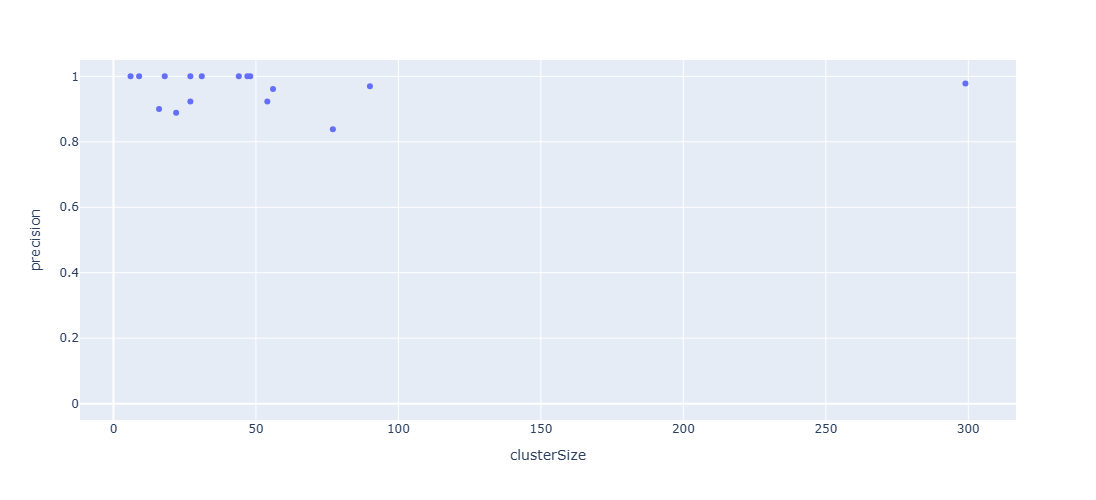

In [25]:
ns.pl.scatter_w_clusterSize(results, "precision", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)

Saving...
 ../outputs_layer1/cluster_scatter_recall.html


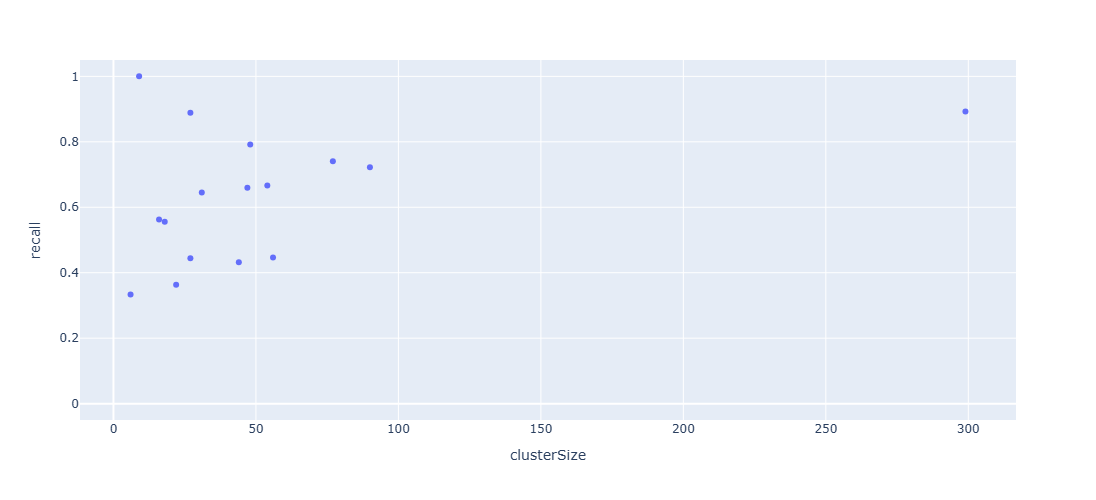

In [26]:
ns.pl.scatter_w_clusterSize(results, "recall", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)

Saving...
 ../outputs_layer1/cluster_scatter_onTarget.html


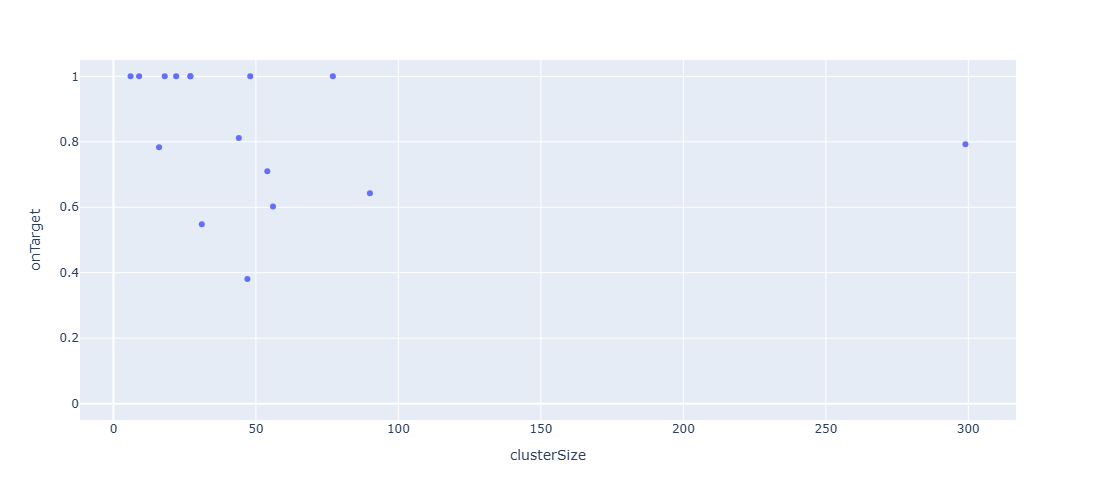

In [27]:
ns.pl.scatter_w_clusterSize(results, "onTarget", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)